step 1 : Define the problem
"Heart disease is one of the leading causes of death worldwide. Diagnosing it requires analyzing several medical parameters, which can be time-consuming. The problem addressed in this project is how to use machine learning to predict whether a patient is likely to have heart disease based on medical data. The goal is to assist healthcare professionals by providing an early prediction that supports faster and more informed clinical decisions."

step 2 : collect the dataset
Data Collection is the process of gathering labeled data from reliable sources.

The quality of the dataset directly affects the model's performance

Here we have chosen the dataset as : HEART DISEASE PREDICTION (collected the dataset from a platform called as kaggle)

In [129]:
#step 3 : import required libraries
#Definition:
#Libraries contain pre-written functions that make machine learning tasks easier.
#Instead of writing everything from scratch, we import the required libraries.-

# Data manipulation
import pandas as pd

# Numerical operations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [130]:
#step 4 :
#uploading the dataset
from google.colab import files
uploaded = files.upload()

Saving Heart_Disease_Prediction.csv to Heart_Disease_Prediction (2).csv


In [131]:
#display the dataset
df=pd.read_csv('Heart_Disease_Prediction.csv')

In [132]:
#display dataset
#A DataFrame is a two-dimensional table-like data structure in the Pandas library. It stores data in rows and columns, similar to an Excel spreadsheet or a SQL table.
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [133]:
#step 5: understand the dataset
#displaying dataset (first 5 rows)
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [134]:
#diaplaying last 5 rows
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [135]:
#displaying the shape (no of rows and no of columns)
df.shape

(270, 14)

In [136]:
#displaying the column names
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [137]:
print(df.columns.tolist())

['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


In [138]:
#data types
df.dtypes

,0
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64
ST depression,float64


In [139]:
#dataset information
#"I used df.info() to understand the structure of the dataset. It helped me verify the number of rows and columns, check for missing values using the non-null count, identify the data types of each feature, and understand the dataset's memory usage before preprocessing."
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [140]:
#statistical summary it shows mean,median,mode,min,max,percentile
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


step 6: DATA CLEANING

In [141]:
#step 6: data cleaning
#checking missing values
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [142]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [143]:
#remove duplicates
df = df.drop_duplicates()

In [144]:
#check unique values
df.nunique

<bound method DataFrame.nunique of      Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0     70    1                4  130          322             0            2   
1     67    0                3  115          564             0            2   
2     57    1                2  124          261             0            0   
3     64    1                4  128          263             0            0   
4     74    0                2  120          269             0            2   
..   ...  ...              ...  ...          ...           ...          ...   
265   52    1                3  172          199             1            0   
266   44    1                2  120          263             0            0   
267   56    0                2  140          294             0            2   
268   57    1                4  140          192             0            0   
269   67    1                4  160          286             0            2   

     Max HR  Exercise angina  ST depression  Slope of ST  \
0       109                0            2.4            2   
1       160                0            1.6            2   
2       141                0            0.3            1   
3       105                1            0.2            2   
4       121                1            0.2            1   
..      ...              ...            ...          ...   
265     162                0            0.5            1   
266     173                0            0.0            1   
267     153                0            1.3            2   
268     148                0            0.4            2   
269     108                1            1.5            2   

     Number of vessels fluro  Thallium Heart Disease  
0                          3         3      Presence  
1                          0         7       Absence  
2                          0         7      Presence  
3                          1         7       Absence  
4                          1         3       Absence  
..                       ...       ...           ...  
265                        0         7       Absence  
266                        0         7       Absence  
267                        0         3       Absence  
268                        0         6       Absence  
269                        3         3      Presence  

[270 rows x 14 columns]>

STEP 7 : EDA(EXPLORATORY DATA ANALYSIS)

"EDA, or Exploratory Data Analysis, is the process of understanding the dataset by using statistical summaries and visualizations. It helps identify patterns, relationships, outliers, and data quality issues before training a machine learning model."

In [145]:
#Definition
#Exploratory Data Analysis (EDA) is the process of analyzing and visualizing the dataset to understand its structure, patterns, relationships, and distributions before building a machine learning model.
#7.1 Display First Five Rows
df.head()
df.tail()
df.shape
df.columns
df.dtypes
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

,0
Age,41
Sex,2
Chest pain type,4
BP,47
Cholesterol,144
FBS over 120,2
EKG results,3
Max HR,90
Exercise angina,2
ST depression,39


In [146]:
#correlation matrix
#A Correlation Matrix is a table that shows the correlation (relationship) between all numerical features in a dataset. It helps us understand how strongly one feature is related to another
df.corr(numeric_only=True)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Age,1.000000,-0.094401,0.096920,0.273053,0.220056,0.123458,0.128171,-0.402215,0.098297,0.194234,0.159774,0.356081,0.106100
Sex,-0.094401,1.000000,0.034636,-0.062693,-0.201647,0.042140,0.039253,-0.076101,0.180022,0.097412,0.050545,0.086830,0.391046
Chest pain type,0.096920,0.034636,1.000000,-0.043196,0.090465,-0.098537,0.074325,-0.317682,0.353160,0.167244,0.136900,0.225890,0.262659
BP,0.273053,-0.062693,-0.043196,1.000000,0.173019,0.155681,0.116157,-0.039136,0.082793,0.222800,0.142472,0.085697,0.132045
Cholesterol,0.220056,-0.201647,0.090465,0.173019,1.000000,0.025186,0.167652,-0.018739,0.078243,0.027709,-0.005755,0.126541,0.028836
FBS over 120,0.123458,0.042140,-0.098537,0.155681,0.025186,1.000000,0.053499,0.022494,-0.004107,-0.025538,0.044076,0.123774,0.049237
EKG results,0.128171,0.039253,0.074325,0.116157,0.167652,0.053499,1.000000,-0.074628,0.095098,0.120034,0.160614,0.114368,0.007337
Max HR,-0.402215,-0.076101,-0.317682,-0.039136,-0.018739,0.022494,-0.074628,1.000000,-0.380719,-0.349045,-0.386847,-0.265333,-0.253397
Exercise angina,0.098297,0.180022,0.353160,0.082793,0.078243,-0.004107,0.095098,-0.380719,1.000000,0.274672,0.255908,0.153347,0.321449
ST depression,0.194234,0.097412,0.167244,0.222800,0.027709,-0.025538,0.120034,-0.349045,0.274672,1.000000,0.609712,0.255005,0.324333


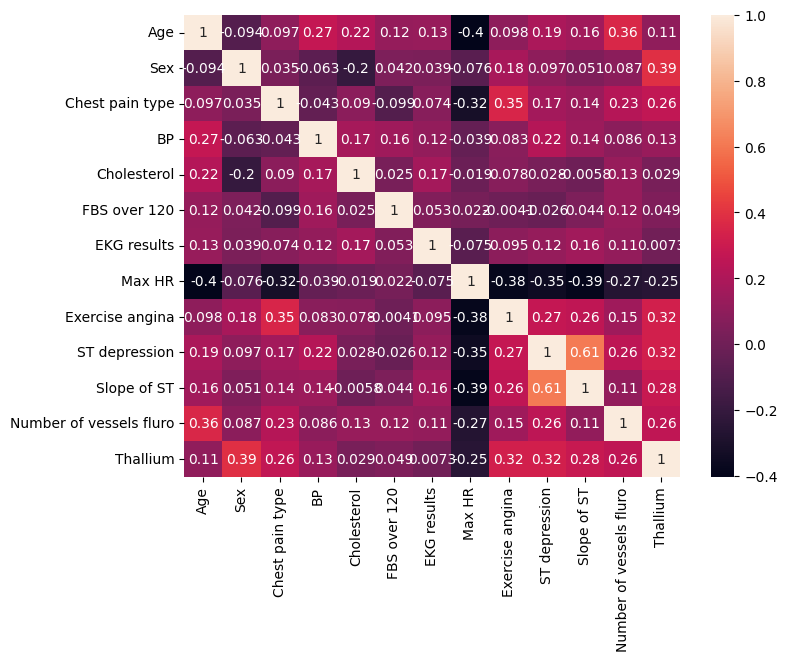

In [147]:
#heatmap
#"This heatmap shows the correlation between all numerical features in the heart disease dataset
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

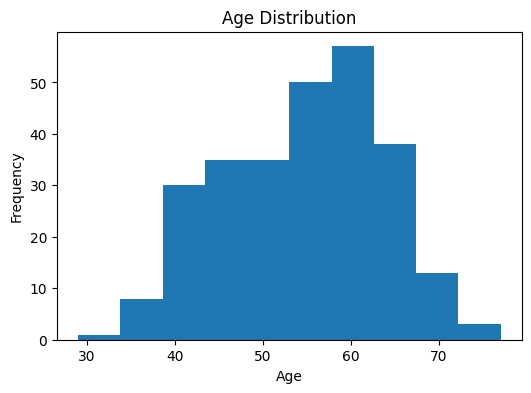

In [148]:
#histogram
#A histogram is a graph used to show the distribution of numerical data by dividing the data into intervals (bins) and displaying how many values fall into each interval
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

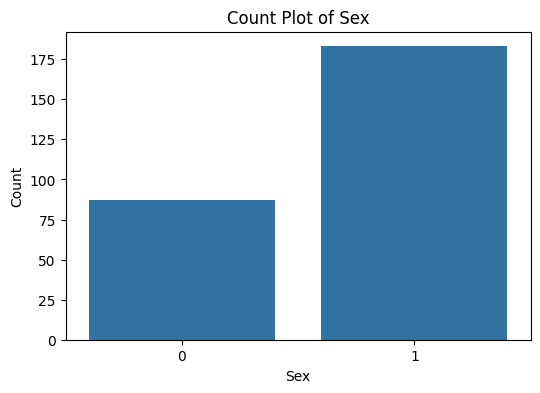

In [149]:
#countplot
#A Count Plot is a graph used to display the number of occurrences (count) of each category in a categorical feature.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)
plt.title("Count Plot of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

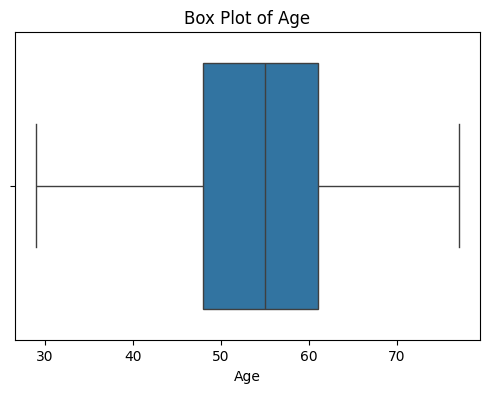

In [150]:
#box plot
#A Box Plot is a statistical graph used to visualize the distribution of numerical data. It shows the minimum value, first quartile (Q1), median (Q2), third quartile (Q3), maximum value, and any outliers
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

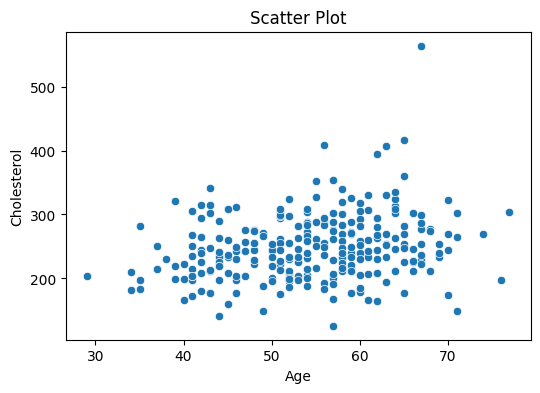

In [151]:
#scatter plot
#I used a Scatter Plot to analyze the relationship between Age and Cholesterol. It helped me understand whether cholesterol levels tend to change as age increases."
#observing patterns and trends(a positive, negative, or no relationship between two variables)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Cholesterol", data=df)
plt.title("Scatter Plot")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

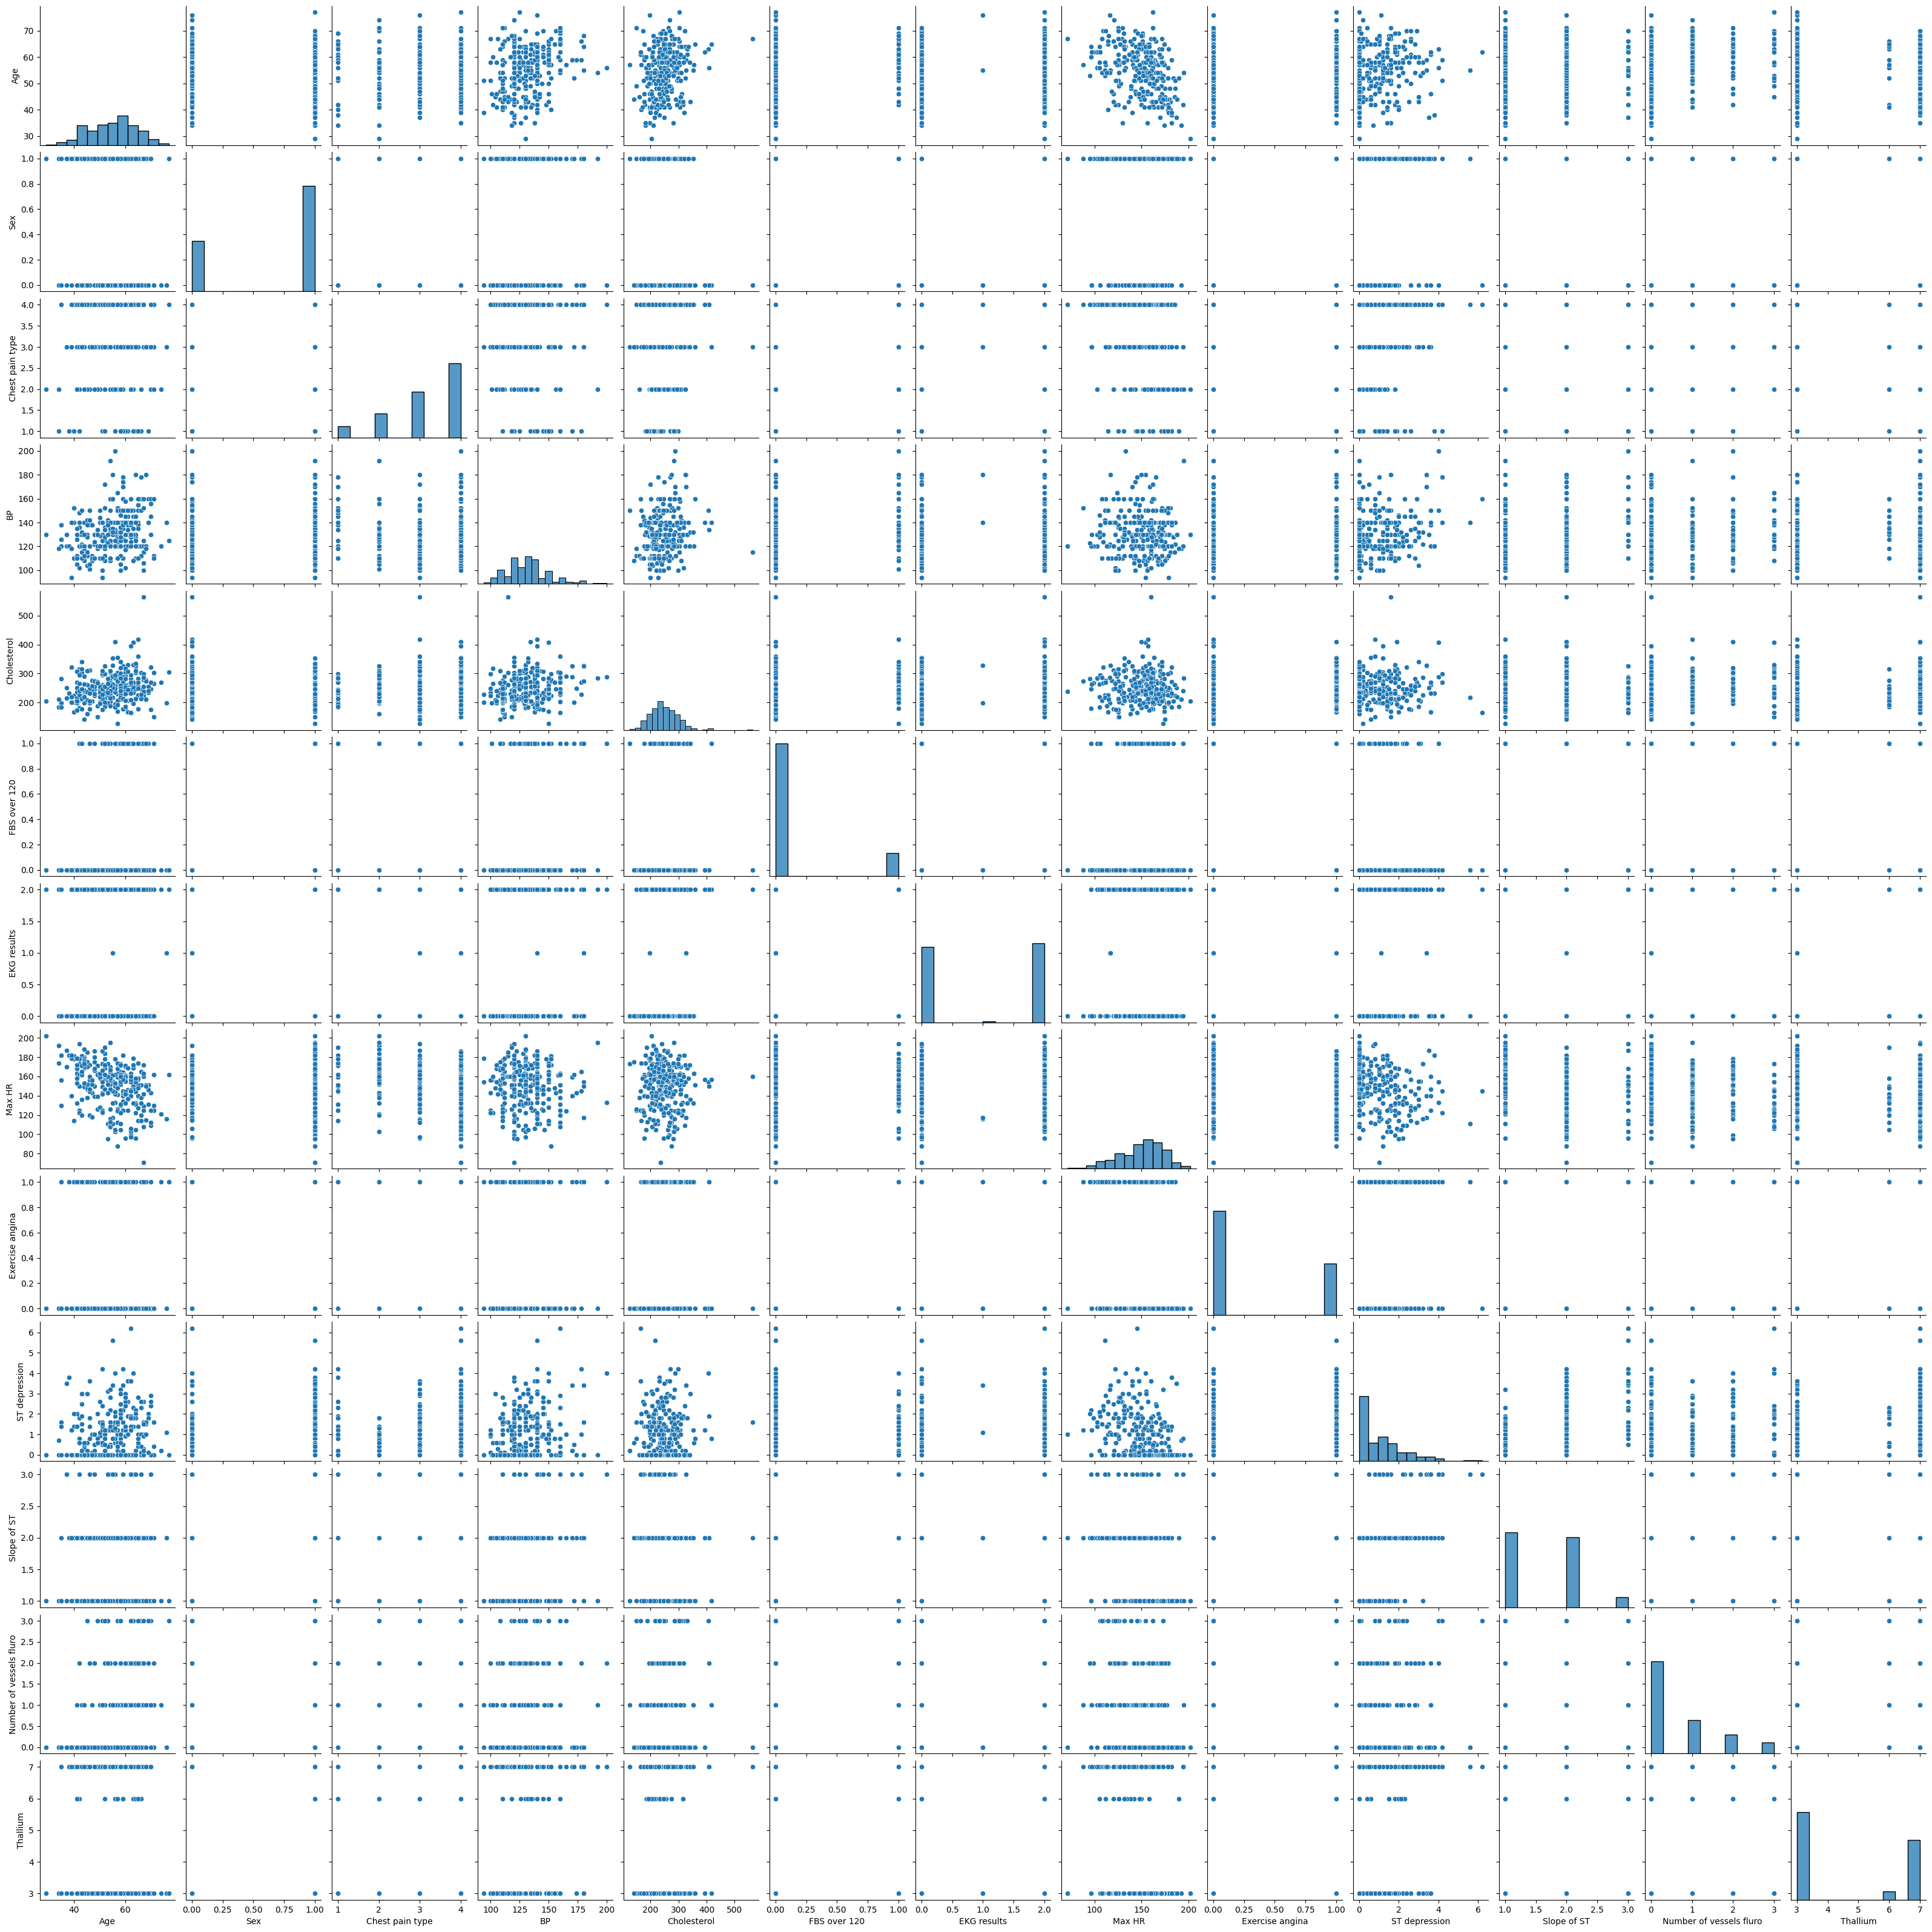

In [152]:
#pair plot
#A Pair Plot is used to visualize the relationships between multiple numerical features
sns.pairplot(df)
plt.show()

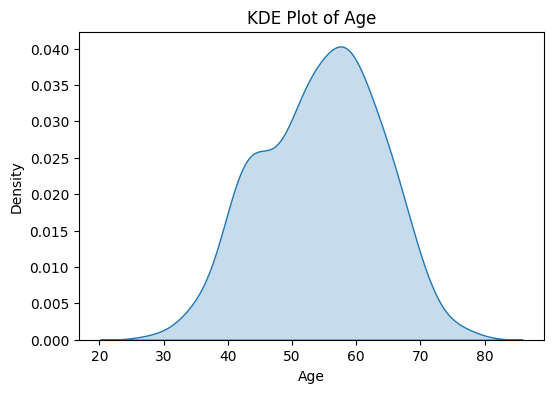

In [153]:
#KDE plot
#"A KDE plot is used to visualize the distribution of a numerical feature as a smooth curve, making it easier to identify where most of the data is concentrated."
plt.figure(figsize=(6,4))
sns.kdeplot(df["Age"], fill=True)
plt.title("KDE Plot of Age")
plt.show()

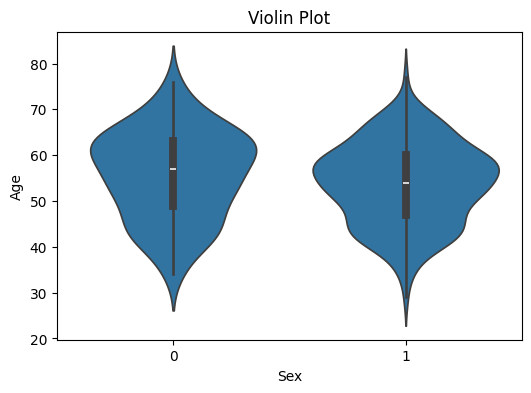

In [154]:
#violin plot
#A Violin Plot is a graph that combines a box plot and a KDE plot to show both the distribution and density of numerical data across different categories.
plt.figure(figsize=(6,4))
sns.violinplot(x="Sex", y="Age", data=df)
plt.title("Violin Plot")
plt.show()

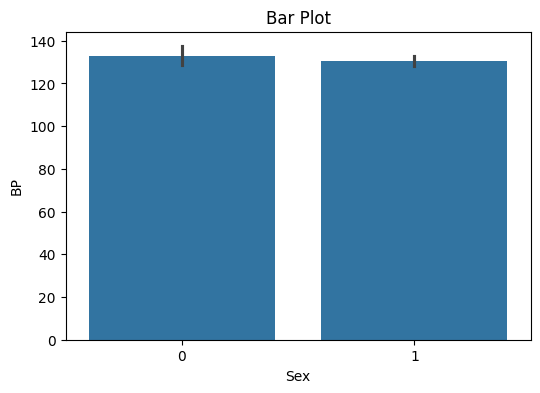

In [155]:
#Bar plot
#A Bar Plot is used to compare the average value of a numerical variable across different categories
plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="BP", data=df)
plt.title("Bar Plot")
plt.show()

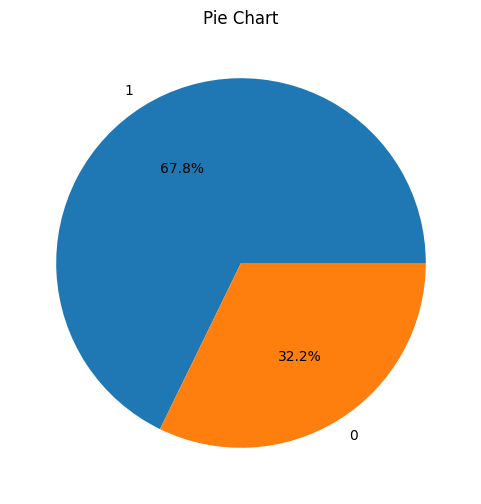

In [156]:
#piechart
#used to show percentage of each category
plt.figure(figsize=(6,6))
df["Sex"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Pie Chart")
plt.ylabel("")
plt.show()

Machine Learning

complete supervised ML workflow

problem statement
⬇
collect dataset ⬇ import library ⬇ load dataset ⬇ understand dataset ⬇ EDA(Exploratory data analysis) ⬇ data cleaining ⬇ feature engineering ⬇ feature selection ⬇ encoding categorical data ⬇ feature scaling ⬇ split dataset ⬇ choose ML algorithm ⬇ train model ⬇ make prediction ⬇ eveluate model ⬇ hyper parameter turning ⬇ save model ⬇ deploy mode

```
# This is formatted as code
```



STEP 8 : DETECT AND HANDLE OUTLIERS

In [157]:
#handling outliers
#Step 1: Calculate Quartiles
#step 8 : detect and handle outliers
#Definition
#Outliers are values that are much higher or lower than the rest of the data
#IQR(Inter Quartile Range)
Q1 = df["Cholesterol"].quantile(0.25)

Q3 = df["Cholesterol"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print(lower)

print(upper)

112.5
380.5


In [158]:
#remove outliers
df = df[(df["Cholesterol"] >= lower) & (df["Cholesterol"] <= upper)]

print("New Dataset Shape:", df.shape)

New Dataset Shape: (265, 14)


STEP 9 : FEATURE ENGINEERING

In [159]:
#Definition
#Feature Engineering is the process of creating, transforming, or improving features to help the model learn better
#Create an Age Group Feature
# Feature Engineering
# Create a new feature based on Cholesterol level
import pandas as pd

# Create a copy of the original dataset
df_fe = df.copy()

# Add a new feature
df_fe["High_Cholesterol"] = (df_fe["Cholesterol"] > 240).astype(int)

# Display the new feature
print(df_fe[["Cholesterol", "High_Cholesterol"]].head())

   Cholesterol  High_Cholesterol
0          322                 1
2          261                 1
3          263                 1
4          269                 1
5          177                 0


STEP 10 : FEATURE SELECTION

In [160]:
#Feature selection:
#Feature selection is the process of choosing the most relevant features for training the model while removing unnecessary ones
X = df.drop("Heart Disease", axis=1) #removes heart disease column
y = df["Heart Disease"]

In [33]:
##Display Feature
X.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Age_Group
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Old
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Middle
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Old
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Old
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Old


In [118]:
##Display Target
print("Target:")
print(y.head())

Target:
0    Presence
2    Presence
3     Absence
4     Absence
5     Absence
Name: Heart Disease, dtype: object


In [126]:
##Check Shapes
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (265, 13)
y Shape: (265,)


STEP 11 : ENCODE CATEGORICAL DATA

In [128]:
##step 11 : Encode categorical data
#Definition
#Encoding is the process of converting categorical (text) data into numerical values so that machine learning algorithms can process them.
print(df.select_dtypes(include=["object", "category"]).columns)

Index([], dtype='object')


In [124]:
##Encode the Categorical Column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Heart Disease"] = le.fit_transform(df["Heart Disease"])


KeyError: 'Heart Disease'

In [121]:
#Encode the Categorical Column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Heart Disease"] = le.fit_transform(df["Heart Disease"])

print(df["Heart Disease"].head())

KeyError: 'Heart Disease'

STEP 12 : FEATURE SCALING

In [120]:
#step 12 : Feature scaling
#standardization using(calculate mean and standard deviation)
#Definition
#"Feature scaling is the process of transforming numerical features to a similar scale so that each feature contributes equally during model training
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Sample data
data = {
    'Age': [25, 40, 60],
    'Cholesterol': [180, 220, 300]
}

df = pd.DataFrame(data)

# Apply Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

print(scaled_df)

        Age  Cholesterol
0 -1.162476    -1.069045
1 -0.116248    -0.267261
2  1.278724     1.336306


STEP 13 : SPLIT THE DATASET

In [89]:
#step 13 : Split the Dataset
#Definition

#Train-Test Split is the process of dividing the dataset into two parts:

#Training Dataset: Used to train the machine learning model.(70%)
#Testing Dataset: Used to evaluate the model's performance on unseen data(30%)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (212, 14)
Testing Features Shape: (53, 14)
Training Target Shape: (212,)
Testing Target Shape: (53,)


SUPERVISED LEARNING :
LOGISTIC REGRESSION AND ITS IMPLEMENTATION

STEP 14 : CHOOSE ALGORITHM

In [90]:
#step 14 : Select a Supervised Learning Algorithm
#1. Logistic Regression
#Definition

#Logistic Regression is a classification algorithm used to predict one of two possible outcomes
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the model
log_model = LogisticRegression(random_state=42)

# Train the model
log_model.fit(X_train, y_train)

# Prediction
y_pred_log = log_model.predict(X_test)

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_log))

# Classification Report
print(classification_report(y_test, y_pred_log))

ValueError: could not convert string to float: 'Elevated'

STEP 15 : TRAIN THE MODEL

In [120]:
#step 15 : Train the Model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [97]:
print(log_model)
print(hasattr(log_model, "coef_"))

LogisticRegression(random_state=42)
False


In [121]:
#save the model:
import joblib

joblib.dump(log_model, "heart_disease_model.pkl")


['heart_disease_model.pkl']

In [122]:
#loading model
import joblib

# Load the saved model
loaded_model = joblib.load("heart_disease_model.pkl")


STEP 16 : MAKE PREDICTIONS

In [123]:
#step 16 : Make Predictions
#Prediction is the process of using the trained model to predict the target values for the testing dataset
# Predict the target values
# Step 16: Make Predictions

# Predict the target values for the test dataset
y_pred = log_model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
['Presence' 'Presence' 'Absence' 'Absence' 'Absence' 'Presence' 'Presence'
 'Absence' 'Absence' 'Absence' 'Absence' 'Presence' 'Presence' 'Presence'
 'Absence' 'Absence' 'Presence' 'Absence' 'Presence' 'Absence' 'Presence'
 'Absence' 'Presence' 'Absence' 'Absence' 'Presence' 'Absence' 'Presence'
 'Absence' 'Absence' 'Absence' 'Absence' 'Presence' 'Absence' 'Absence'
 'Presence' 'Presence' 'Absence' 'Presence' 'Absence' 'Absence' 'Absence'
 'Absence' 'Absence' 'Absence' 'Absence' 'Absence' 'Presence' 'Presence'
 'Absence' 'Absence' 'Absence' 'Absence' 'Presence']


In [124]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9074074074074074
Accuracy (%): 90.74074074074075


In [125]:
#evaluate model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9074074074074074


In [126]:
#(b) Confusion Matrix

#Definition: A confusion matrix compares the actual values with the predicted values
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[31  2]
 [ 3 18]]


In [77]:
#(c) Classification Report

#Definition: The classification report summarizes the model's performance using precision, recall, F1-score, and support
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

     Absence       0.91      0.94      0.93        33
    Presence       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



In [80]:
# Save the original Logistic Regression model
import joblib

joblib.dump(log_model, "heart_disease_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Original Model Saved Successfully!")

Original Model Saved Successfully!


In [81]:
import joblib

loaded_model = joblib.load("heart_disease_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [82]:
import os

print(os.listdir())

['.config', 'heart_disease_model.pkl', 'Heart_Disease_Prediction (1).csv', 'scaler.pkl', 'Heart_Disease_Prediction.csv', 'sample_data']


In [84]:
print(loaded_model)

LogisticRegression(random_state=42)


In [58]:
print(X.columns.tolist())

['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


In [85]:
import pandas as pd

new_patient = pd.DataFrame([[63, 1, 3, 233, 1, 0, 150, 0, 2.3, 0, 0, 1, 2]],
                           columns=X.columns)

In [88]:
#scale input
new_patient_scaled = loaded_scaler.transform(new_patient)

In [89]:
#Predict
prediction = loaded_model.predict(new_patient_scaled)

In [90]:
#Display the Result
if prediction[0] == 1:
    print("Prediction: Heart Disease Present")
else:
    print("Prediction: Heart Disease Absent")

Prediction: Heart Disease Absent


In [65]:
from google.colab import files

files.download("heart_disease_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [68]:
print(log_model)


LogisticRegression(random_state=42)


In [69]:
from sklearn.metrics import accuracy_score

y_pred = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9074074074074074


In [70]:
import joblib

joblib.dump(log_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [72]:
from google.colab import files

files.download("heart_disease_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>